# 🧹 Data Preprocessing

## Project: Student Performance Prediction

### Objective

The purpose of this notebook is to prepare the dataset for Machine Learning by performing:

- Data quality verification
- Outlier analysis
- Feature encoding
- Feature scaling
- Train-test split
- Saving the processed dataset

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load DataSet
df = pd.read_csv("../data/raw/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Dataset Shape
print('Dataset Shape:', df.shape)
df.info()

Dataset Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
# Check Missing Value
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Observation
### The dataset contains no missing value

In [5]:
# Check Duplicates
df.duplicated().sum()

np.int64(0)

## Observation
### No Duplicate records were found

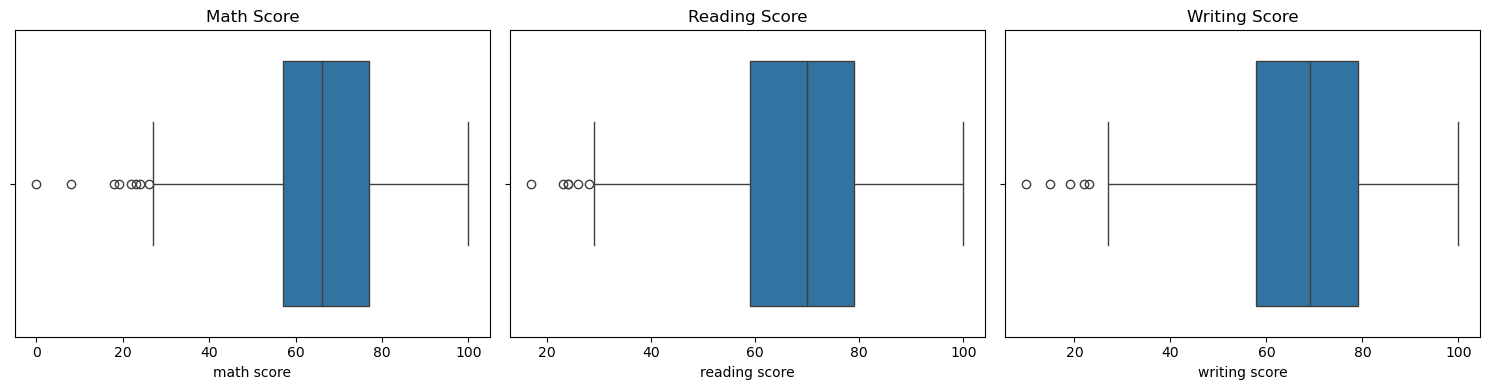

In [6]:
# Outlier Analysis
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(x=df['math score'])
plt.title('Math Score')

plt.subplot(1,3,2)
sns.boxplot(x=df['reading score'])
plt.title('Reading Score')

plt.subplot(1,3,3)
sns.boxplot(x=df['writing score'])
plt.title('Writing Score')

plt.tight_layout()
plt.show()

## Observation
- Some outliers are present.
- These values may represent genuine student performace rather than errors.
- Therefore, no outliers are removed

In [7]:
# Separate Feature & Target
X = df.drop('math score', axis=1)
y = df['math score']

In [8]:
# Categorical & Numerical Columns

categorical_columns = X.select_dtypes(include='object').columns
numerical_columns = X.select_dtypes(exclude= 'object').columns

print('Categorical Columns')

print(categorical_columns)

print()

print("Numerical Columns")

print(numerical_columns)

Categorical Columns
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')

Numerical Columns
Index(['reading score', 'writing score'], dtype='object')


In [9]:
# One-Hot Encoding
encoder = OneHotEncoder(
    drop='first',
    sparse_output=False
)
encoded = encoder.fit_transform(
    X[categorical_columns]
)

encoded_df = pd.DataFrame(
    encoded,
    columns= encoder.get_feature_names_out(categorical_columns)
)

encoded_df.head()

,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


In [10]:
# Scale Numerical Features
scaler = StandardScaler()

scaled = scaler.fit_transform(
    X[numerical_columns]
)

scaled_df = pd.DataFrame(
    scaled,
    columns= numerical_columns
)

scaled_df.head()

,reading score,writing score
0,0.193999,0.391492
1,1.427476,1.313269
2,1.770109,1.642475
3,-0.833899,-1.583744
4,0.605158,0.457333


In [11]:
# Combine Features
X_processed = pd.concat(
    [
        scaled_df.reset_index(drop=True),
        encoded_df.reset_index(drop=True)
    ],
    axis=1
)
X_processed.head()

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,0.193999,0.391492,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1.427476,1.313269,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.770109,1.642475,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,-0.833899,-1.583744,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.605158,0.457333,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0


In [12]:
# Trian-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state= 42
)
print('Training:', X_train.shape)
print('Testing:', X_test.shape)

Training: (800, 14)
Testing: (200, 14)


In [13]:
# Save Processed Dataset
processed_df = pd.concat(
    [
        X_processed,
        y.reset_index(drop=True)
    ],
    axis=1
)
processed_df.to_csv(
    '../data/processed/processed_student.csv',
    index=False
)

print("✅ Processed dataset saved successfully!")

✅ Processed dataset saved successfully!


In [14]:
# Verification
df_processed = pd.read_csv(
    '../data/processed/processed_student.csv'
)

df_processed.head()

,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none,math score
0,0.193999,0.391492,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,72
1,1.427476,1.313269,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,69
2,1.770109,1.642475,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,90
3,-0.833899,-1.583744,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,47
4,0.605158,0.457333,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,76


# ✅ Preprocessing Summary

The following preprocessing steps were completed successfully:

- Loaded the dataset
- Verified missing values
- Verified duplicate records
- Analyzed outliers
- Applied One-Hot Encoding to categorical features
- Applied StandardScaler to numerical features
- Split data into training and testing sets
- Saved the processed dataset

The dataset is now ready for Machine Learning model training.

In [16]:
import joblib
joblib.dump(encoder, "../models/encoder.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']